# Salifort Motors - Employee Attrition Prediction

## Machine Learning Project

**Autor:** Ángel Araya Robles

Este proyecto analiza los factores asociados a la rotación de empleados utilizando técnicas de análisis exploratorio de datos (EDA) y modelos de Machine Learning.

Modelos utilizados:
- Logistic Regression
- XGBoost

# Contenido

1. Introducción
2. Preparación de datos
3. Análisis exploratorio (EDA)
4. Visualizaciones
5. Regresión Logística
6. XGBoost
7. Comparación de modelos
8. Conclusiones
9. Recomendaciones

## Objetivo

Analizar los factores asociados a la rotación de empleados mediante análisis exploratorio de datos (EDA) y modelos de Machine Learning para apoyar la toma de decisiones del área de Recursos Humanos.

## Tecnologías utilizadas

- Python
- Pandas
- NumPy
- Matplotlib
- Seaborn
- Scikit-learn
- XGBoost
- Jupyter Notebook

## Project Methodology (PACE)

### Understand the business scenario and problem

The HR department at Salifort Motors wants to take some initiatives to improve employee satisfaction levels at the company. They collected data from employees, but now they don’t know what to do with it. They refer to you as a data analytics professional and ask you to provide data-driven suggestions based on your understanding of the data. They have the following question: what’s likely to make the employee leave the company?

Your goals in this project are to analyze the data collected by the HR department and to build a model that predicts whether or not an employee will leave the company.

If you can predict employees likely to quit, it might be possible to identify factors that contribute to their leaving. Because it is time-consuming and expensive to find, interview, and hire new employees, increasing employee retention will be beneficial to the company.

### Familiarize yourself with the HR dataset

The dataset that you'll be using in this lab contains 15,000 rows and 10 columns for the variables listed below. 

**Note:** you don't need to download any data to complete this lab. For more information about the data, refer to its source on [Kaggle](https://www.kaggle.com/datasets/mfaisalqureshi/hr-analytics-and-job-prediction?select=HR_comma_sep.csv).

Variable  |Description |
-----|-----|
satisfaction_level|Employee-reported job satisfaction level [0&ndash;1]|
last_evaluation|Score of employee's last performance review [0&ndash;1]|
number_project|Number of projects employee contributes to|
average_monthly_hours|Average number of hours employee worked per month|
time_spend_company|How long the employee has been with the company (years)
Work_accident|Whether or not the employee experienced an accident while at work
left|Whether or not the employee left the company
promotion_last_5years|Whether or not the employee was promoted in the last 5 years
Department|The employee's department
salary|The employee's salary (U.S. dollars)

## Business Understanding

### Problema

Salifort Motors busca comprender qué factores influyen en la rotación de empleados para reducir la pérdida de talento.

### Objetivo del análisis

Desarrollar un modelo predictivo capaz de identificar empleados con mayor probabilidad de abandonar la empresa y entregar información útil para apoyar decisiones del área de Recursos Humanos.

# 1. Importación de librerías

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay)

from xgboost import XGBClassifier

pd.set_option("display.max_columns", None)

# 2. Carga de datos

Se carga el conjunto de datos utilizado para analizar los factores asociados a la rotación de empleados.

In [2]:
df0 = pd.read_csv("HR_capstone_dataset.csv")

In [3]:
df0.describe(include="all")

,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,left,promotion_last_5years,Department,salary
count,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000,14999,14999
unique,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,10,3
top,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,sales,low
freq,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4140,7316
mean,0.612834,0.716102,3.803054,201.050337,3.498233,0.144610,0.238083,0.021268,NaN,NaN
std,0.248631,0.171169,1.232592,49.943099,1.460136,0.351719,0.425924,0.144281,NaN,NaN
min,0.090000,0.360000,2.000000,96.000000,2.000000,0.000000,0.000000,0.000000,NaN,NaN
25%,0.440000,0.560000,3.000000,156.000000,3.000000,0.000000,0.000000,0.000000,NaN,NaN
50%,0.640000,0.720000,4.000000,200.000000,3.000000,0.000000,0.000000,0.000000,NaN,NaN
75%,0.820000,0.870000,5.000000,245.000000,4.000000,0.000000,0.000000,0.000000,NaN,NaN


### Observaciones iniciales

- El conjunto de datos original contiene 14.999 registros y 10 variables.
- No se observan valores faltantes.
- Existen variables numéricas y categóricas.
- La variable objetivo es `left`, donde 0 representa que el empleado permanece y 1 que abandona la empresa.

# 3. Exploración inicial de los datos (EDA)


## Información general del conjunto de datos

In [4]:
df0.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14999 entries, 0 to 14998
Data columns (total 10 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   satisfaction_level     14999 non-null  float64
 1   last_evaluation        14999 non-null  float64
 2   number_project         14999 non-null  int64  
 3   average_montly_hours   14999 non-null  int64  
 4   time_spend_company     14999 non-null  int64  
 5   Work_accident          14999 non-null  int64  
 6   left                   14999 non-null  int64  
 7   promotion_last_5years  14999 non-null  int64  
 8   Department             14999 non-null  object 
 9   salary                 14999 non-null  object 
dtypes: float64(2), int64(6), object(2)
memory usage: 1.1+ MB


## Estadísticas descriptivas

In [5]:
df0.describe(include="all")

,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,left,promotion_last_5years,Department,salary
count,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000,14999,14999
unique,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,10,3
top,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,sales,low
freq,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4140,7316
mean,0.612834,0.716102,3.803054,201.050337,3.498233,0.144610,0.238083,0.021268,NaN,NaN
std,0.248631,0.171169,1.232592,49.943099,1.460136,0.351719,0.425924,0.144281,NaN,NaN
min,0.090000,0.360000,2.000000,96.000000,2.000000,0.000000,0.000000,0.000000,NaN,NaN
25%,0.440000,0.560000,3.000000,156.000000,3.000000,0.000000,0.000000,0.000000,NaN,NaN
50%,0.640000,0.720000,4.000000,200.000000,3.000000,0.000000,0.000000,0.000000,NaN,NaN
75%,0.820000,0.870000,5.000000,245.000000,4.000000,0.000000,0.000000,0.000000,NaN,NaN


### Observaciones iniciales

- El conjunto de datos original contiene 14.999 registros.
- No se observan valores faltantes.
- El dataset contiene variables numéricas y categóricas.
- La variable objetivo es `left`, donde 0 representa que el empleado permanece y 1 que abandona la empresa.

# 4. Limpieza de datos

Se estandarizan los nombres de las variables utilizando el formato `snake_case` para mejorar la legibilidad y mantener una nomenclatura consistente.

## Revisión de valores faltantes

In [6]:
df0 = df0.rename(columns={
    "number_project": "number_projects",
    "average_montly_hours": "average_monthly_hours",
    "time_spend_company": "tenure",
    "Work_accident": "work_accident",
    "Department": "department"})


In [7]:
df0.columns

Index(['satisfaction_level', 'last_evaluation', 'number_projects',
       'average_monthly_hours', 'tenure', 'work_accident', 'left',
       'promotion_last_5years', 'department', 'salary'],
      dtype='object')

**Resultado:** Todas las columnas fueron renombradas correctamente utilizando una nomenclatura uniforme.

## Revisión de registros duplicados

Se verifica la existencia de valores nulos en cada variable del conjunto de datos.

In [8]:
df0.isna().sum()

satisfaction_level       0
last_evaluation          0
number_projects          0
average_monthly_hours    0
tenure                   0
work_accident            0
left                     0
promotion_last_5years    0
department               0
salary                   0
dtype: int64

No se encontraron valores faltantes en ninguna de las variables, por lo que no fue necesario realizar imputaciones ni eliminar registros.

## Detección de valores atípicos (Outliers)

Se identifican registros duplicados para evitar que afecten el rendimiento de los modelos de Machine Learning.

In [9]:
duplicados = df0.duplicated().sum()
print("Cantidad de registros duplicados:", duplicados)

Cantidad de registros duplicados: 3008


Se identificaron **3008 registros duplicados**.

In [10]:
df = df0.drop_duplicates().copy()

print("Dimensión original:", df0.shape)
print("Dimensión después de eliminar duplicados:", df.shape)

Dimensión original: (14999, 10)
Dimensión después de eliminar duplicados: (11991, 10)


Debido a que los registros duplicados pueden introducir sesgos en el entrenamiento de los modelos, se eliminan manteniendo únicamente observaciones únicas.

## Detección de valores atípicos (Outliers)

Se analiza la distribución de la variable **tenure** mediante un diagrama de caja (boxplot) para identificar posibles valores atípicos que puedan influir en el entrenamiento de los modelos predictivos.

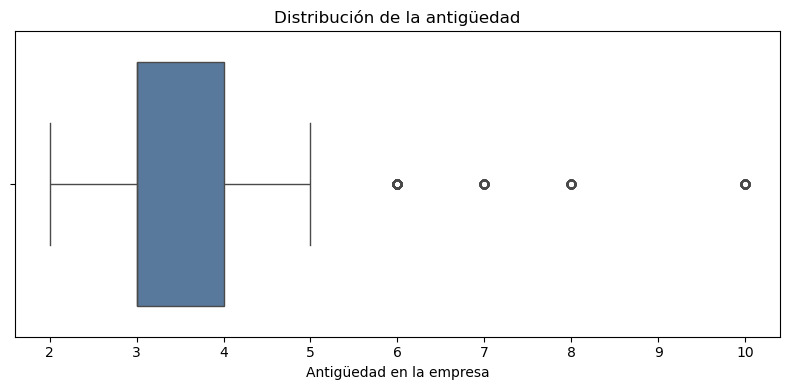

In [11]:
plt.figure(figsize=(8, 4))

sns.boxplot(
    x=df["tenure"],
    color="#4E79A7")

plt.title("Distribución de la antigüedad")
plt.xlabel("Antigüedad en la empresa")
plt.tight_layout()
plt.show()

El boxplot muestra la presencia de algunos valores atípicos en la variable **tenure**, principalmente en empleados con una permanencia considerablemente superior al resto de la muestra.

Para cuantificar los valores atípicos se utiliza el método del **Rango Intercuartílico (IQR)**, definiendo como outliers aquellas observaciones ubicadas fuera del intervalo:

- Límite inferior = Q1 − 1.5 × IQR
- Límite superior = Q3 + 1.5 × IQR

In [12]:
Q1 = df["tenure"].quantile(0.25)
Q3 = df["tenure"].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers = df[
    (df["tenure"] < lower) |
    (df["tenure"] > upper)
]

print("Número de valores atípicos:", outliers.shape[0])

Número de valores atípicos: 824


Se identificaron **824 valores atípicos** en la variable **tenure**.

Estos registros no fueron eliminados debido a que representan empleados con una antigüedad elevada, lo cual constituye una característica válida del negocio y puede aportar información relevante para la predicción de la rotación.

# 5. Análisis Exploratorio de Datos (EDA)

## Objetivo del análisis exploratorio

En esta etapa se exploran las principales características del conjunto de datos con el fin de comprender el comportamiento de los empleados e identificar factores asociados a la rotación.

Durante el análisis se evaluarán:

- Distribución de la variable objetivo.
- Relación entre la rotación y las variables numéricas.
- Relación entre la rotación y las variables categóricas.
- Correlaciones entre variables.
- Patrones que puedan ser útiles para el desarrollo de modelos predictivos.

## Distribución de la variable objetivo

In [13]:
df["left"].value_counts()

df["left"].value_counts(normalize=True) * 100

left
0    83.39588
1    16.60412
Name: proportion, dtype: float64

### Observaciones

Se observa que aproximadamente el **83 %** de los empleados permanecen en la empresa, mientras que cerca del **17 %** abandonan la organización.

Esto indica un desbalance moderado entre las clases, aspecto que debe considerarse durante el entrenamiento y evaluación de los modelos predictivos.

# 6. Visualización y análisis de variables

En esta sección se analizan las principales variables del conjunto de datos mediante visualizaciones para identificar patrones relacionados con la rotación de empleados.

## Distribución de la rotación de empleados

Se analiza la cantidad de empleados que permanecieron en la empresa y aquellos que abandonaron la organización.

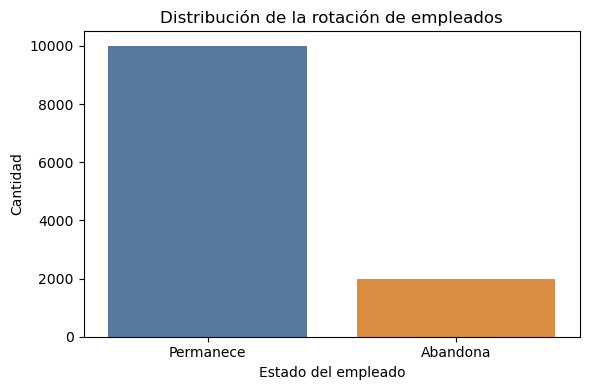

In [14]:
plt.figure(figsize=(6, 4))

sns.countplot(
    data=df,
    x="left",
    hue="left",
    palette=["#4E79A7", "#F28E2B"],
    legend=False
)

plt.title("Distribución de la rotación de empleados")
plt.xlabel("Estado del empleado")
plt.ylabel("Cantidad")

plt.xticks(
    ticks=[0, 1],
    labels=["Permanece", "Abandona"]
)

plt.tight_layout()
plt.show()

La mayoría de los empleados permanecen en la empresa, mientras que una menor proporción corresponde a empleados que abandonaron la organización.

Este desbalance debe considerarse durante el entrenamiento y evaluación de los modelos predictivos.

## Nivel de satisfacción según la rotación

Se compara el nivel de satisfacción entre los empleados que permanecieron en la empresa y aquellos que renunciaron.

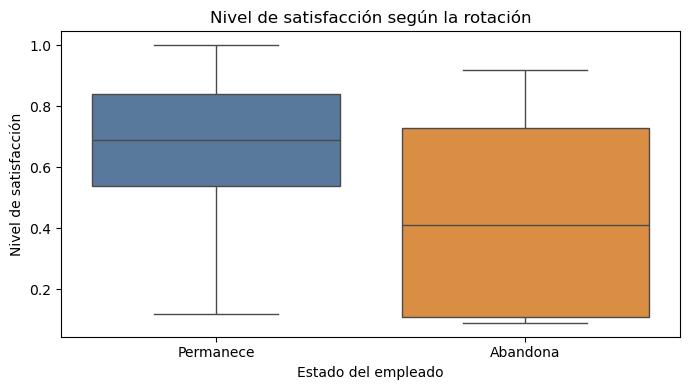

In [15]:
plt.figure(figsize=(7,4))

sns.boxplot(
    data=df,
    x="left",
    y="satisfaction_level",
    hue="left",
    palette=["#4E79A7", "#F28E2B"],
    legend=False
)

plt.title("Nivel de satisfacción según la rotación")
plt.xlabel("Estado del empleado")
plt.ylabel("Nivel de satisfacción")

plt.xticks(
    ticks=[0,1],
    labels=["Permanece","Abandona"]
)

plt.tight_layout()
plt.show()

Los empleados que abandonaron la empresa presentan, en promedio, un nivel de satisfacción considerablemente menor que quienes permanecieron.

Esto sugiere que la satisfacción laboral es uno de los factores más relevantes asociados a la rotación de empleados.

## Horas mensuales trabajadas según la rotación

Se compara la cantidad de horas trabajadas mensualmente entre los empleados que permanecieron en la empresa y aquellos que abandonaron la organización.

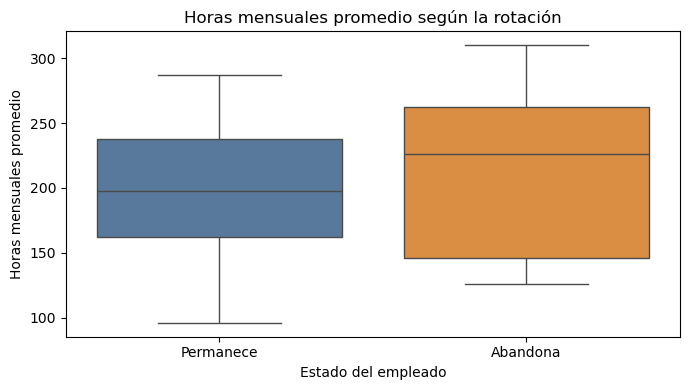

In [16]:
plt.figure(figsize=(7,4))

sns.boxplot(
    data=df,
    x="left",
    y="average_monthly_hours",
    hue="left",
    palette=["#4E79A7", "#F28E2B"],
    legend=False
)

plt.title("Horas mensuales promedio según la rotación")
plt.xlabel("Estado del empleado")
plt.ylabel("Horas mensuales promedio")

plt.xticks(
    ticks=[0,1],
    labels=["Permanece","Abandona"]
)

plt.tight_layout()
plt.show()

### Interpretación

Los empleados que abandonaron la empresa presentan, en promedio, una mayor cantidad de horas trabajadas al mes.

Este resultado sugiere que una mayor carga laboral podría estar asociada con un mayor riesgo de rotación.

## Número de proyectos según la rotación

Se analiza la distribución del número de proyectos asignados a los empleados según su estado dentro de la empresa.

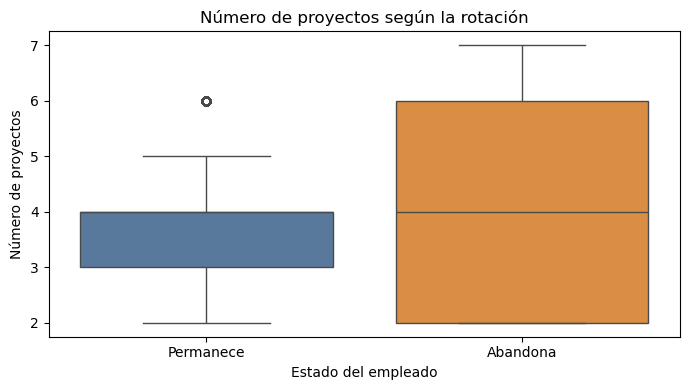

In [17]:
plt.figure(figsize=(7,4))

sns.boxplot(
    data=df,
    x="left",
    y="number_projects",
    hue="left",
    palette=["#4E79A7", "#F28E2B"],
    legend=False
)

plt.title("Número de proyectos según la rotación")
plt.xlabel("Estado del empleado")
plt.ylabel("Número de proyectos")

plt.xticks(
    ticks=[0,1],
    labels=["Permanece","Abandona"]
)

plt.tight_layout()
plt.show()

### Interpretación

Los empleados que abandonaron la empresa muestran una mayor variabilidad en el número de proyectos.

Esto podría indicar que una carga de trabajo elevada influye en la decisión de abandonar la organización.

## Rotación según nivel salarial

Se analiza la distribución de empleados que permanecieron y abandonaron la empresa según su nivel salarial.

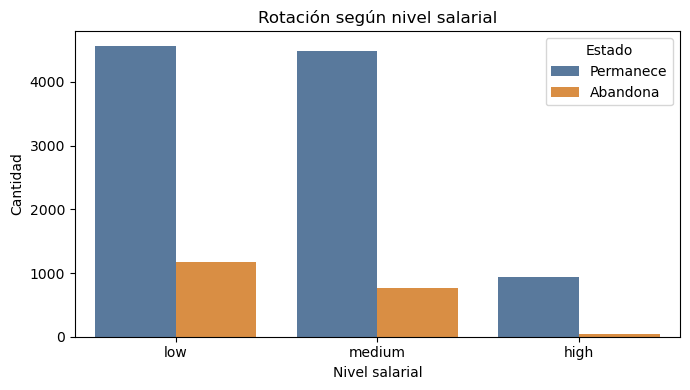

In [18]:
plt.figure(figsize=(7, 4))

sns.countplot(
    data=df,
    x="salary",
    hue="left",
    palette=["#4E79A7", "#F28E2B"]
)

plt.title("Rotación según nivel salarial")
plt.xlabel("Nivel salarial")
plt.ylabel("Cantidad")

plt.legend(
    title="Estado",
    labels=["Permanece", "Abandona"]
)

plt.tight_layout()
plt.show()

### Interpretación

La tasa de rotación es mayor entre los empleados con salarios bajos y disminuye en los niveles salariales superiores.

Este resultado indica que el nivel de compensación puede estar asociado con la permanencia de los empleados. Sin embargo, el análisis muestra una asociación y no permite concluir por sí solo que el salario sea la causa de la rotación.

## Rotación por departamento

Se compara la cantidad de empleados que permanecieron y abandonaron la empresa en cada departamento.

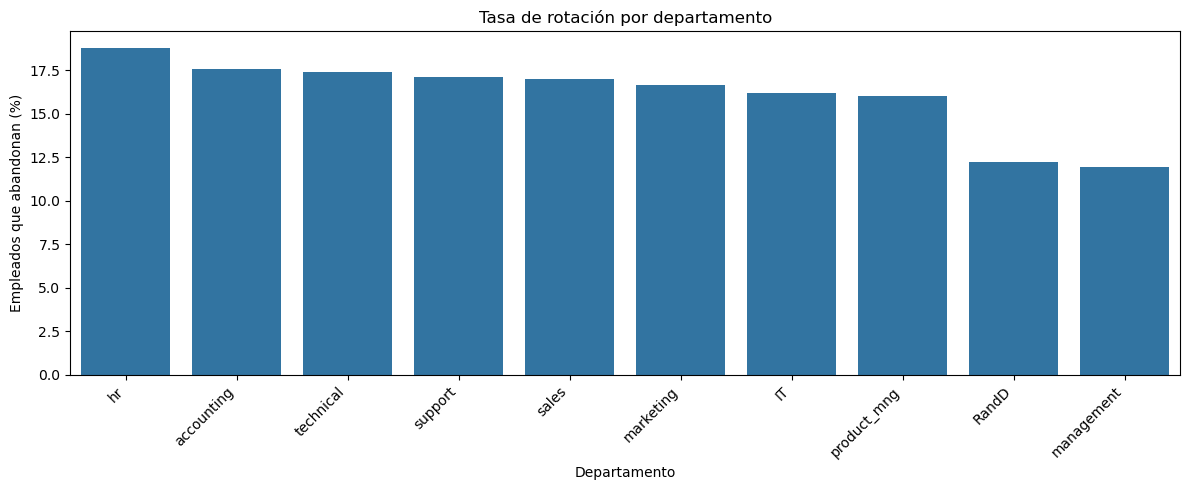

,department,left
0,hr,18.801997
1,accounting,17.552335
2,technical,17.379679
3,support,17.133443
4,sales,16.980550
5,marketing,16.641902
6,IT,16.188525
7,product_mng,16.034985
8,RandD,12.247839
9,management,11.926606


In [19]:
department_turnover = (
    df.groupby("department", observed=False)["left"]
      .mean()
      .mul(100)
      .sort_values(ascending=False)
      .reset_index()
)

plt.figure(figsize=(12, 5))

sns.barplot(
    data=department_turnover,
    x="department",
    y="left"
)

plt.title("Tasa de rotación por departamento")
plt.xlabel("Departamento")
plt.ylabel("Empleados que abandonan (%)")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

department_turnover

### Interpretación

La tasa de rotación presenta diferencias entre departamentos. Esta visualización permite comparar áreas de distinto tamaño utilizando porcentajes y no solamente cantidades absolutas.

Las diferencias observadas pueden orientar análisis posteriores, pero no demuestran que pertenecer a un departamento sea por sí solo la causa del abandono.

## Antigüedad de los empleados según la rotación

Se analiza la distribución de la antigüedad de los empleados en la empresa para comparar a quienes permanecieron con quienes abandonaron la organización.

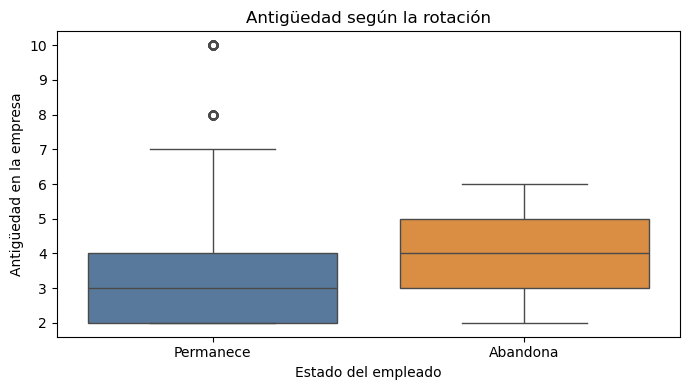

In [20]:
plt.figure(figsize=(7, 4))

sns.boxplot(
    data=df,
    x="left",
    y="tenure",
    hue="left",
    palette=["#4E79A7", "#F28E2B"],
    legend=False
)

plt.title("Antigüedad según la rotación")
plt.xlabel("Estado del empleado")
plt.ylabel("Antigüedad en la empresa")

plt.xticks(
    ticks=[0, 1],
    labels=["Permanece", "Abandona"]
)

plt.tight_layout()
plt.show()

### Interpretación

Los empleados que abandonaron la empresa presentan, en promedio, una mayor antigüedad que aquellos que permanecieron.

Además, se observan algunos valores atípicos correspondientes a empleados con muchos años de permanencia. Estos resultados sugieren que la antigüedad podría estar relacionada con la probabilidad de rotación y será considerada durante el entrenamiento de los modelos predictivos.

## Matriz de correlación

Se calcula la matriz de correlación para identificar la relación entre las variables numéricas del conjunto de datos y detectar aquellas que presentan mayor asociación con la rotación de empleados.

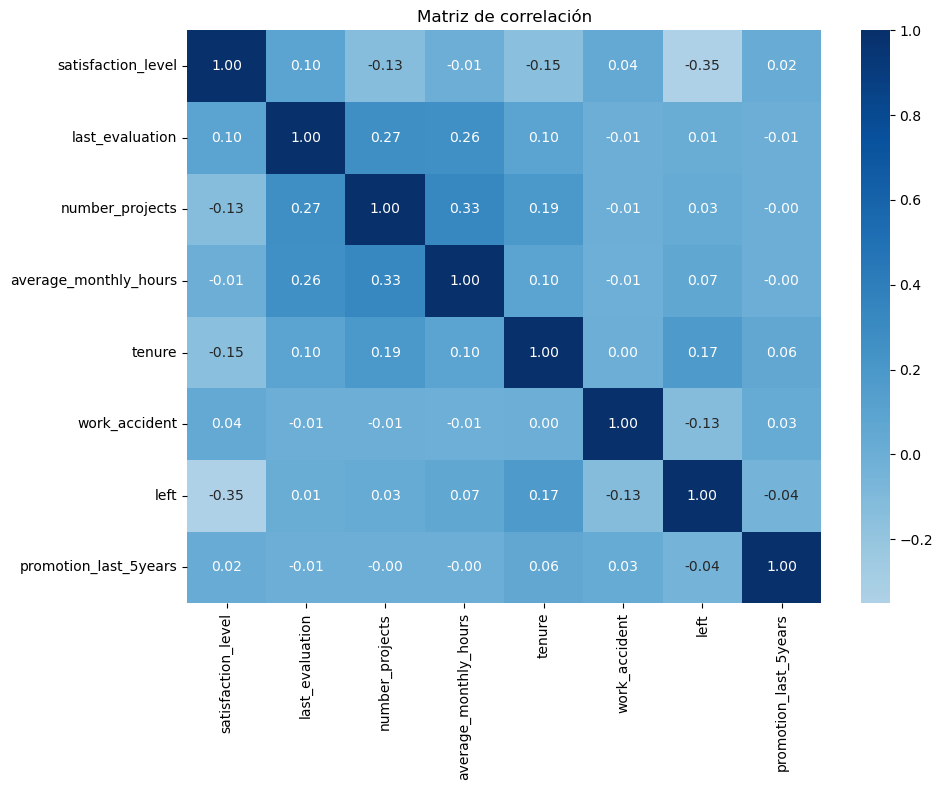

In [21]:
plt.figure(figsize=(10, 8))

numeric_df = df.select_dtypes(include="number")

sns.heatmap(
    numeric_df.corr(),
    annot=True,
    fmt=".2f",
    cmap="Blues",
    center=0
)

plt.title("Matriz de correlación")
plt.tight_layout()
plt.show()

### Interpretación

El nivel de satisfacción presenta la asociación lineal más fuerte con la rotación, con una correlación negativa aproximada de -0,35.

La antigüedad presenta una asociación positiva débil, mientras que el número de proyectos y las horas mensuales muestran correlaciones lineales muy bajas con la variable objetivo.

Una correlación baja no significa necesariamente que una variable sea inútil para el modelo, ya que XGBoost también puede detectar relaciones no lineales e interacciones entre variables.

# Conclusiones del análisis exploratorio

El análisis exploratorio permitió identificar patrones relevantes asociados a la rotación de empleados.

Entre las variables con mayor influencia destacan:

- Nivel de satisfacción.
- Antigüedad en la empresa.
- Número de proyectos.
- Horas trabajadas mensualmente.
- Nivel salarial.

Estos resultados respaldan el desarrollo de modelos predictivos para estimar la probabilidad de que un empleado abandone la organización.

# 7. Modelado Predictivo


En esta etapa se construyen y comparan dos modelos de clasificación para predecir si un empleado abandonará la empresa:

- Regresión Logística
- XGBoost

El rendimiento se evaluará mediante Accuracy, Precision, Recall, F1 Score, ROC-AUC y matrices de confusión.

## 7.1 Preparación de los datos

Las variables categóricas `department` y `salary` se transforman en variables numéricas mediante codificación one-hot.

Luego se separa la variable objetivo `left` de las variables predictoras y se divide el conjunto de datos en entrenamiento y prueba.

In [22]:
df_model = pd.get_dummies(
    df,
    columns=["department", "salary"],
    drop_first=True)

In [23]:
y = df_model["left"]

X = df_model.drop("left", axis=1)

In [24]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y)

In [25]:
print("Entrenamiento:", X_train.shape)
print("Prueba:", X_test.shape)

Entrenamiento: (9592, 18)
Prueba: (2399, 18)


El 80 % de los datos se utiliza para entrenar los modelos y el 20 % restante para evaluarlos. La opción `stratify=y` mantiene la proporción original de empleados que permanecen y abandonan la empresa.

## 7.2 Modelo 1: Regresión Logística

La Regresión Logística se utiliza como modelo base para problemas de clasificación binaria.

En este caso, el objetivo es predecir si un empleado abandonará la empresa.

In [26]:
model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

model.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,42
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


### Resultados

Se evalúa el rendimiento del modelo utilizando Accuracy, Precision, Recall, F1 Score y ROC AUC.

In [27]:
y_pred = model.predict(X_test)

y_prob = model.predict_proba(X_test)[:,1]

In [28]:
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)


print(f"Accuracy:  {accuracy:.3f}")
print(f"Precision: {precision:.3f}")
print(f"Recall:    {recall:.3f}")
print(f"F1 Score:  {f1:.3f}")


Accuracy:  0.835
Precision: 0.506
Recall:    0.211
F1 Score:  0.298


In [29]:
print(classification_report(
    y_test,
    y_pred,
    target_names=["Permanece", "Abandona"]))

              precision    recall  f1-score   support

   Permanece       0.86      0.96      0.91      2001
    Abandona       0.51      0.21      0.30       398

    accuracy                           0.83      2399
   macro avg       0.68      0.59      0.60      2399
weighted avg       0.80      0.83      0.81      2399



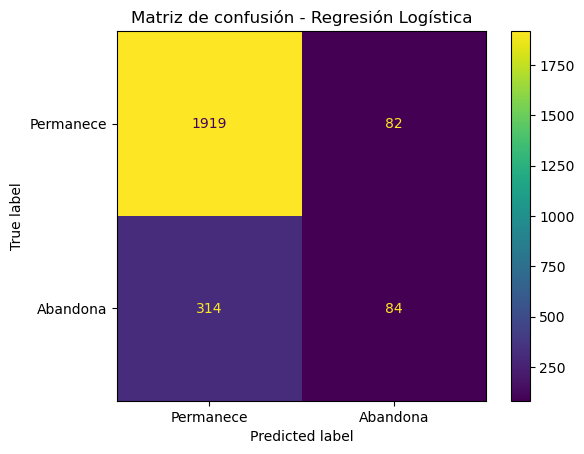

In [30]:
cm_log = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_log,
    display_labels=["Permanece", "Abandona"])

disp.plot()
plt.title("Matriz de confusión - Regresión Logística")
plt.show()

### Interpretación

La Regresión Logística obtiene una exactitud general aceptable; sin embargo, presenta un recall bajo para la clase de empleados que abandonan la empresa.

El modelo identifica correctamente a la mayoría de quienes permanecen, pero no detecta una proporción importante de empleados con riesgo de salida. Por esta razón, es necesario comparar su desempeño con un modelo más avanzado.

## 7.3 Modelo 2: XGBoost

XGBoost es un algoritmo basado en árboles de decisión que generalmente obtiene un mejor rendimiento en problemas de clasificación.

Posteriormente se comparará con la Regresión Logística.

In [31]:
xgb_model = XGBClassifier(
    n_estimators=200,
    max_depth=4,
    learning_rate=0.1,
    random_state=42,
    eval_metric="logloss"
)

xgb_model.fit(X_train, y_train)

,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,True
,eval_metric,'logloss'


In [32]:
xgb_pred = xgb_model.predict(X_test)

xgb_prob = xgb_model.predict_proba(X_test)[:,1]

### Evaluación del modelo

El rendimiento de XGBoost se evalúa mediante Accuracy, Precision, Recall, F1 Score y ROC-AUC.

In [33]:
accuracy_xgb = accuracy_score(y_test, xgb_pred)
precision_xgb = precision_score(y_test, xgb_pred)
recall_xgb = recall_score(y_test, xgb_pred)
f1_xgb = f1_score(y_test, xgb_pred)

print(f"Accuracy:  {accuracy_xgb:.3f}")
print(f"Precision: {precision_xgb:.3f}")
print(f"Recall:    {recall_xgb:.3f}")
print(f"F1 Score:  {f1_xgb:.3f}")

Accuracy:  0.982
Precision: 0.959
Recall:    0.932
F1 Score:  0.945


In [34]:
print(classification_report(
    y_test,
    xgb_pred,
    target_names=["Permanece", "Abandona"]))

              precision    recall  f1-score   support

   Permanece       0.99      0.99      0.99      2001
    Abandona       0.96      0.93      0.95       398

    accuracy                           0.98      2399
   macro avg       0.97      0.96      0.97      2399
weighted avg       0.98      0.98      0.98      2399



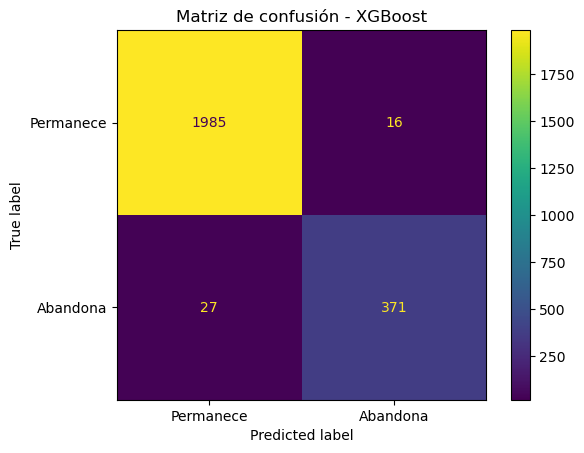

In [35]:
cm_xgb = confusion_matrix(y_test, xgb_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_xgb,
    display_labels=["Permanece", "Abandona"]
)

disp.plot()
plt.title("Matriz de confusión - XGBoost")
plt.show()

### Interpretación

XGBoost presenta un desempeño considerablemente superior a la Regresión Logística.

El modelo identifica correctamente a la mayoría de los empleados que abandonan la empresa y reduce significativamente los falsos negativos. Esto es especialmente importante porque permite detectar una mayor proporción de empleados con riesgo de salida.

## 7.4 Importancia de variables

Se analiza la importancia asignada por XGBoost a cada variable para identificar los factores que más influyen en la predicción de la rotación de empleados.

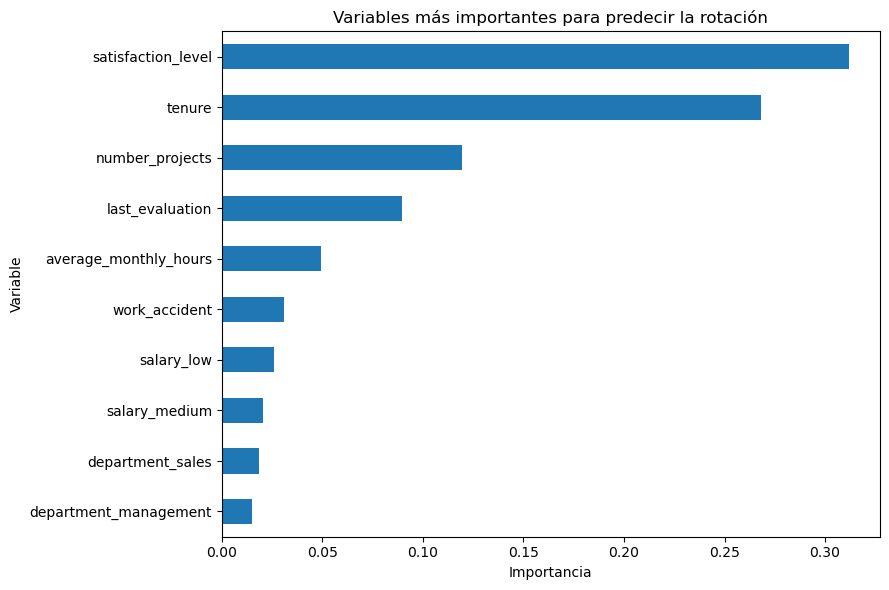

In [36]:
feature_importance = pd.Series(
    xgb_model.feature_importances_,
    index=X_train.columns
).sort_values(ascending=False)

plt.figure(figsize=(9, 6))

feature_importance.head(10).sort_values().plot(
    kind="barh"
)

plt.title("Variables más importantes para predecir la rotación")
plt.xlabel("Importancia")
plt.ylabel("Variable")
plt.tight_layout()
plt.show()

### Interpretación

Las variables con mayor influencia para predecir la rotación fueron:

- Nivel de satisfacción.
- Antigüedad en la empresa.
- Número de proyectos.
- Última evaluación.
- Horas mensuales trabajadas.

El nivel de satisfacción fue el factor más importante para el modelo, seguido por la antigüedad y la cantidad de proyectos asignados.

## 7.5 Comparación de modelos

Se comparan los resultados de la Regresión Logística y XGBoost mediante Accuracy, Precision, Recall, F1 Score y ROC-AUC.

In [40]:
comparison = pd.DataFrame({
    "Modelo":["Regresión Logística","XGBoost"],
    "Accuracy":[accuracy, accuracy_xgb],
    "Precision":[precision, precision_xgb],
    "Recall":[recall, recall_xgb],
    "F1 Score":[f1, f1_xgb]
})

comparison.round(3)

,Modelo,Accuracy,Precision,Recall,F1 Score
0,Regresión Logística,0.835,0.506,0.211,0.298
1,XGBoost,0.982,0.959,0.932,0.945


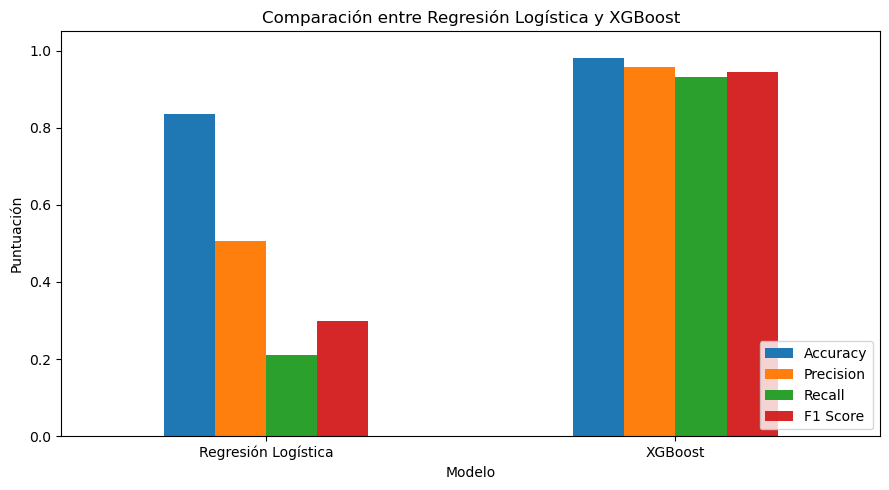

In [41]:
comparison.set_index("Modelo")[
    ["Accuracy", "Precision", "Recall", "F1 Score"]
].plot(
    kind="bar",
    figsize=(9, 5)
)

plt.title("Comparación entre Regresión Logística y XGBoost")
plt.xlabel("Modelo")
plt.ylabel("Puntuación")
plt.xticks(rotation=0)
plt.ylim(0, 1.05)
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

### Conclusión de la comparación

XGBoost obtuvo un rendimiento ampliamente superior a la Regresión Logística en todas las métricas evaluadas.

La Regresión Logística presentó una exactitud general aceptable, pero tuvo dificultades para detectar a los empleados que abandonan la empresa, como demuestra su bajo Recall.

XGBoost alcanzó aproximadamente:

- 98 % de Accuracy.
- 96 % de Precision.
- 93 % de Recall.
- 95 % de F1 Score.
- 98 % de ROC-AUC.

Por este motivo, XGBoost se selecciona como el modelo final para apoyar la identificación de empleados con mayor riesgo de rotación.

# 8. Conclusiones

El proyecto permitió analizar los factores asociados a la rotación de empleados y construir modelos predictivos para apoyar la toma de decisiones de Recursos Humanos.

### Interpretación

Las variables con mayor importancia para las predicciones de XGBoost fueron:

- Nivel de satisfacción.
- Antigüedad en la empresa.
- Número de proyectos.
- Última evaluación.
- Horas mensuales trabajadas.

El nivel de satisfacción fue la variable más utilizada por el modelo. Sin embargo, esta medida no indica por sí sola la dirección del efecto ni demuestra una relación causal.

# 9. Recomendaciones para Recursos Humanos

A partir de los resultados obtenidos se recomienda:

- Medir periódicamente el nivel de satisfacción laboral.
- Revisar la distribución de proyectos y las horas mensuales trabajadas.
- Identificar tempranamente a los empleados con señales de sobrecarga laboral.
- Diseñar estrategias de retención para los perfiles con mayor riesgo de salida.
- Fortalecer las oportunidades de desarrollo y crecimiento profesional.
- Utilizar el modelo como herramienta de apoyo y no como único criterio para tomar decisiones laborales.
- Proteger la privacidad de los empleados y evaluar periódicamente posibles sesgos del modelo.